In [3]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

import joblib

import warnings
warnings.filterwarnings('ignore')

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\cheta\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\cheta\AppData\Roaming\nltk_data...


True

In [6]:
df = pd.read_csv("customer_support_tickets.csv")
print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [8]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [9]:
df = df[['Ticket Description',
         'Ticket Type',
         'Ticket Priority']]

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

print(df.shape)

(8342, 3)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8342 entries, 0 to 8468
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Ticket Description  8342 non-null   object
 1   Ticket Type         8342 non-null   object
 2   Ticket Priority     8342 non-null   object
dtypes: object(3)
memory usage: 260.7+ KB


In [11]:
df.isnull().sum()

Ticket Description    0
Ticket Type           0
Ticket Priority       0
dtype: int64

In [12]:
df.describe()

,Ticket Description,Ticket Type,Ticket Priority
count,8342,8342,8342
unique,8077,5,4
top,I'm having an issue with the {product_purchase...,Refund request,Medium
freq,17,1722,2155


In [13]:
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words('english'))

def clean_text(text):
    
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return " ".join(words)

In [14]:
df['cleaned_text'] = df['Ticket Description'].apply(clean_text)

print(df[['Ticket Description',
          'cleaned_text']].head())

                                  Ticket Description  \
0  I'm having an issue with the {product_purchase...   
1  I'm having an issue with the {product_purchase...   
2  I'm facing a problem with my {product_purchase...   
3  I'm having an issue with the {product_purchase...   
4  I'm having an issue with the {product_purchase...   

                                        cleaned_text  
0  issue product purchased please assist billing ...  
1  issue product purchased please assist need cha...  
2  facing problem product purchased product purch...  
3  issue product purchased please assist problem ...  
4  issue product purchased please assist note sel...  


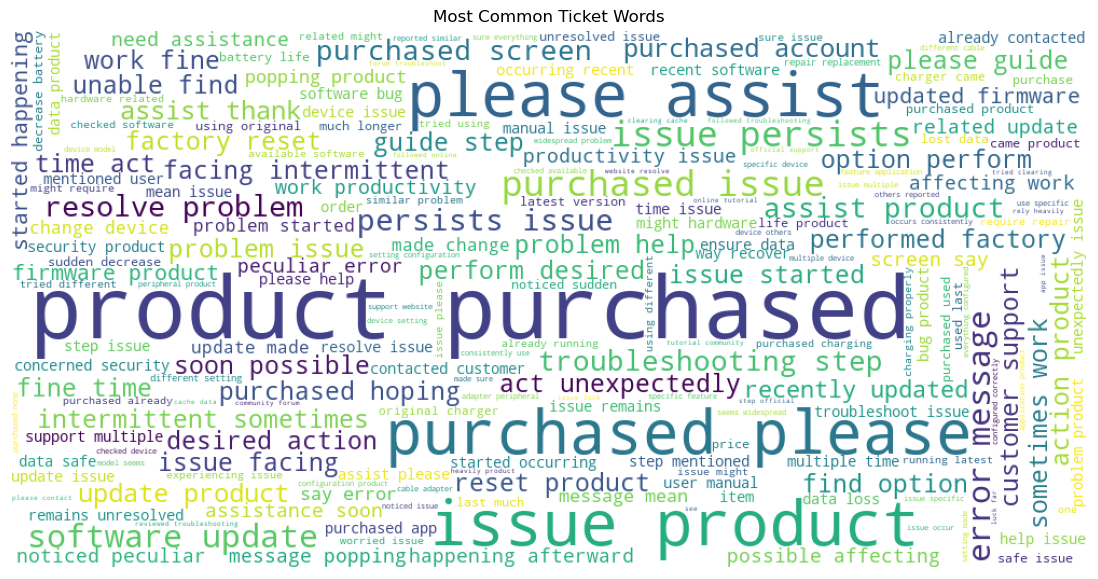

In [15]:
all_words = " ".join(df['cleaned_text'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Most Common Ticket Words")

plt.show()

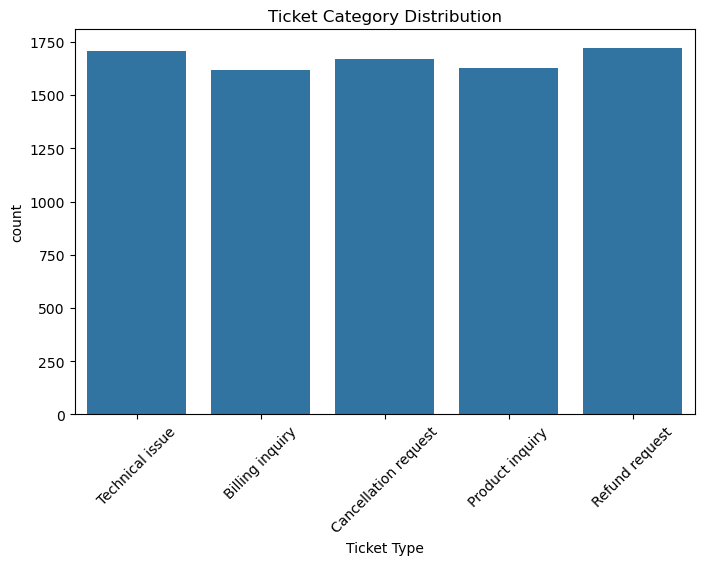

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df['Ticket Type']
)

plt.title("Ticket Category Distribution")

plt.xticks(rotation=45)

plt.show()

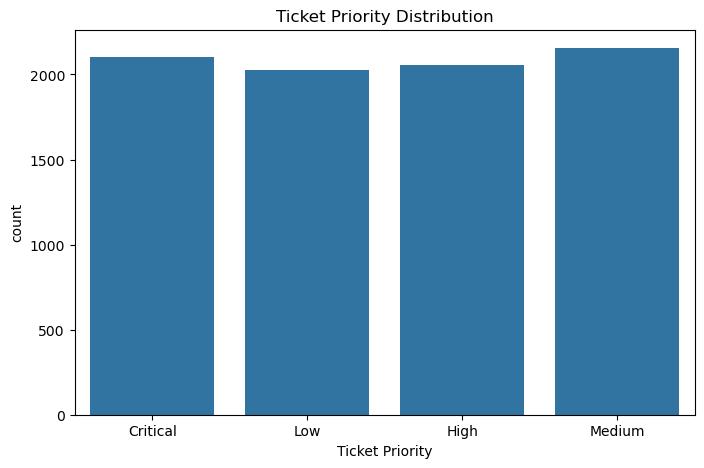

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df['Ticket Priority']
)

plt.title("Ticket Priority Distribution")

plt.show()

In [18]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text'])

In [19]:
y_category = df['Ticket Type']

In [20]:
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42
)

In [21]:
category_model = LogisticRegression()

category_model.fit(
    X_train_cat,
    y_train_cat
)

LogisticRegression()

In [22]:
y_pred_cat = category_model.predict(X_test_cat)

In [23]:
print("CATEGORY CLASSIFICATION RESULTS")

print("Accuracy:",
      accuracy_score(y_test_cat, y_pred_cat))

print(classification_report(
    y_test_cat,
    y_pred_cat
))

CATEGORY CLASSIFICATION RESULTS
Accuracy: 0.2025164769322948
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.18      0.19       322
Cancellation request       0.17      0.19      0.18       324
     Product inquiry       0.20      0.19      0.19       315
      Refund request       0.21      0.21      0.21       355
     Technical issue       0.23      0.24      0.23       353

            accuracy                           0.20      1669
           macro avg       0.20      0.20      0.20      1669
        weighted avg       0.20      0.20      0.20      1669



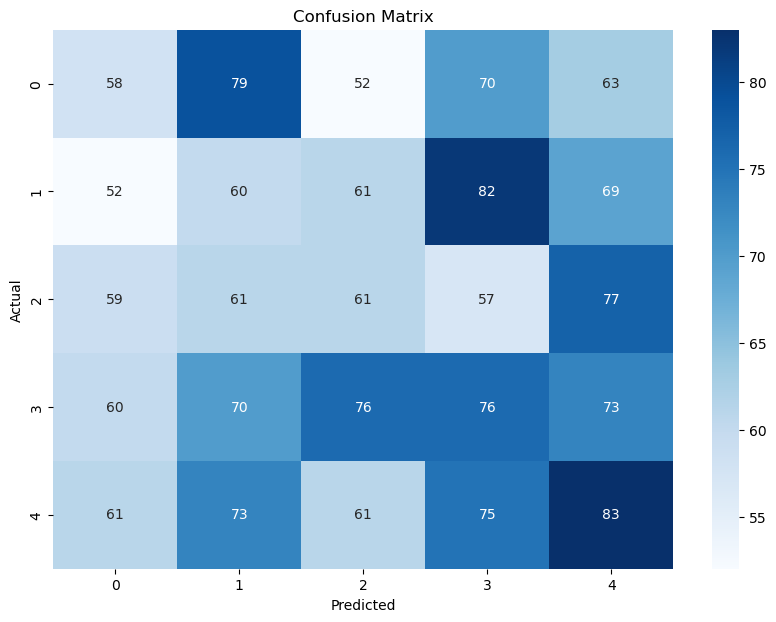

In [24]:
cm = confusion_matrix(
    y_test_cat,
    y_pred_cat
)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [25]:
y_priority = df['Ticket Priority']

In [26]:
X_train_pri, X_test_pri, y_train_pri, y_test_pri = train_test_split(
    X,
    y_priority,
    test_size=0.2,
    random_state=42
)

In [27]:
priority_model = LogisticRegression()

priority_model.fit(
    X_train_pri,
    y_train_pri
)

LogisticRegression()

In [28]:
y_pred_pri = priority_model.predict(X_test_pri)

In [29]:
print("PRIORITY PREDICTION RESULTS")

print("Accuracy:",
      accuracy_score(y_test_pri, y_pred_pri))

print(classification_report(
    y_test_pri,
    y_pred_pri
))

PRIORITY PREDICTION RESULTS
Accuracy: 0.2468544038346315
              precision    recall  f1-score   support

    Critical       0.24      0.26      0.25       404
        High       0.22      0.22      0.22       402
         Low       0.24      0.22      0.23       408
      Medium       0.28      0.29      0.28       455

    accuracy                           0.25      1669
   macro avg       0.25      0.25      0.25      1669
weighted avg       0.25      0.25      0.25      1669



In [30]:
sample_ticket = """
My payment failed and I cannot access my account.
"""

cleaned_ticket = clean_text(sample_ticket)

vectorized_ticket = tfidf.transform([cleaned_ticket])

predicted_category = category_model.predict(
    vectorized_ticket
)[0]

predicted_priority = priority_model.predict(
    vectorized_ticket
)[0]

print("Ticket:", sample_ticket)

print("Predicted Category:",
      predicted_category)

print("Predicted Priority:",
      predicted_priority)

Ticket: 
My payment failed and I cannot access my account.

Predicted Category: Product inquiry
Predicted Priority: Medium


In [31]:
joblib.dump(category_model,
            'category_model.pkl')

joblib.dump(priority_model,
            'priority_model.pkl')

joblib.dump(tfidf,
            'tfidf.pkl')

['tfidf.pkl']